# SOTA embeddings: text, images, and search

This notebook demonstrates **text embeddings** (local and cloud), **image embeddings** with CLIP, and how to compare **semantic** vs **keyword** retrieval.

## What you will use

| Stack | Role |
|-------|------|
| **Hugging Face Hub** | Download open models (`sentence-transformers`, CLIP). The finetuning chapter goes deeper into HF. |
| **LangChain** | Unified wrappers for **Google Gemini** and **OpenAI** embedding APIs. |
| **Local `.env`** | `GOOGLE_API_KEY`, `HF_TOKEN`, `OPENAI_API_KEY` (optional per section). |

Run the environment cell first so API keys are available to `os.getenv()`.


In [1]:
import os
from pathlib import Path

from dotenv import load_dotenv

# .env is only a file on disk; load it into the process so os.getenv() can see it.
_cwd = Path.cwd()
for _env in (_cwd / ".env", _cwd.parent / ".env"):
    if _env.is_file():
        load_dotenv(_env, override=True)

for _key in ("GOOGLE_API_KEY", "HF_TOKEN", "OPENAI_API_KEY"):
    _val = os.getenv(_key)
    if _val is not None:
        os.environ[_key] = _val

## 1. Open-source text embeddings (Sentence Transformers)

[`sentence-transformers`](https://www.sentence-transformers.org/) loads models from the Hugging Face Hub. Here we use **`all-MiniLM-L6-v2`**: a small, fast model that maps text to a **384-dimensional** vector.

**Encode** turns a string (word, sentence, or paragraph) into one embedding. The output dimension is fixed regardless of input length—the model pools token representations into a single vector.


In [2]:
from sentence_transformers import SentenceTransformer

In [3]:
open_source_embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
text = "machine"

In [5]:
embedding =open_source_embedding_model.encode(text)

In [6]:
embedding

array([-7.21354410e-02,  2.84874551e-02, -1.17706126e-02,  1.98008772e-02,
       -4.34783362e-02, -3.14590000e-02,  1.49604762e-02,  2.88986880e-03,
        3.24487640e-03, -3.39518748e-02,  1.04992324e-02, -1.02071995e-02,
        7.77680576e-02, -7.65563995e-02, -1.39956153e-03, -2.10193056e-03,
        1.71924122e-02, -6.33648485e-02, -2.81336661e-02, -5.86969182e-02,
       -3.29725407e-02,  1.02291368e-02, -6.45695478e-02,  1.98799595e-02,
       -1.06031718e-02,  1.04793400e-01, -3.81070636e-02,  5.03518507e-02,
        2.06003450e-02, -1.30085513e-01, -2.18260307e-02,  4.07632394e-03,
        6.23156593e-05,  2.95541510e-02,  3.27022821e-02, -1.54474946e-02,
        3.09898946e-02, -3.76024656e-02,  1.37064802e-02, -5.00646792e-02,
        2.30320916e-02, -7.93177933e-02, -8.26479936e-06, -1.97606366e-02,
        7.49427527e-02,  1.02477886e-01,  6.01520436e-03, -3.98588106e-02,
        5.47021888e-02,  3.11047509e-02, -1.16405949e-01, -7.04230592e-02,
        6.45304993e-02,  

In [7]:
len(embedding)

384

In [8]:
embedding.shape

(384,)

In [9]:
sentence = "How to reduce heart disease risk?"

In [10]:
embedding =open_source_embedding_model.encode(sentence)

In [11]:
embedding.shape

(384,)

In [12]:
paragraph = """
Machine learning is a field of artificial intelligence that focuses on building systems 
that learn from data. It is widely used in applications like recommendation systems, 
image recognition, and natural language processing.
"""

In [13]:
embedding = open_source_embedding_model.encode(paragraph)

In [14]:
embedding.shape

(384,)

In [15]:
embedding

array([-2.78186798e-02, -6.40660478e-03,  3.68497372e-02,  2.21404689e-03,
        2.55084336e-02,  1.34023083e-02,  6.45566639e-03, -3.05500831e-02,
       -6.01915084e-02, -2.28518229e-02, -7.05490112e-02,  1.97643787e-02,
        5.54116145e-02, -3.38736176e-02, -9.74510424e-03,  4.72750515e-02,
       -1.58115178e-02, -1.64723676e-02, -6.00375310e-02, -7.00236335e-02,
        2.54246928e-02, -5.45074092e-03, -7.51983076e-02,  1.57804154e-02,
       -1.62698328e-02,  5.30246682e-02,  6.29331246e-02,  1.47748403e-02,
       -1.32339094e-02,  5.44597255e-03,  2.14248747e-02, -3.44793163e-02,
        1.16899069e-02,  4.35766652e-02, -4.42826711e-02,  5.05335182e-02,
       -2.66971309e-02,  5.36211208e-03,  7.96867721e-03, -1.89669728e-02,
       -6.25875518e-02, -7.47380704e-02,  6.55541150e-03, -6.77178428e-03,
        1.26145527e-01,  1.28760204e-01, -7.31318668e-02, -9.79881287e-02,
        8.16384214e-04,  1.73747130e-02, -1.05541214e-01,  1.18358172e-02,
       -1.23240715e-02,  

## 2. Google Gemini embeddings (LangChain)

[`GoogleGenerativeAIEmbeddings`](https://python.langchain.com/docs/integrations/text_embedding/google_generative_ai/) calls Google's API. Model **`gemini-embedding-001`** returns a higher-dimensional vector (e.g. **3072** floats) than MiniLM.

Requires `GOOGLE_API_KEY` in the environment.


In [16]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

In [17]:
google_embeddings_model = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

In [18]:
embedding = google_embeddings_model.embed_query("What is the capital of France?")

In [19]:
len(embedding)

3072

## 3. OpenAI embeddings (LangChain)

[`OpenAIEmbeddings`](https://python.langchain.com/docs/integrations/text_embedding/openai/) uses **`text-embedding-3-large`** (3072 dims) and **`text-embedding-3-small`** (1536 dims). Dimensions depend on the model.

Set a valid **`OPENAI_API_KEY`** in `.env`. If the key is missing or placeholder, the embed call returns **401 AuthenticationError** (visible in the saved output below).


In [20]:
from langchain_openai import OpenAIEmbeddings

In [21]:
openai_embeddings_model=OpenAIEmbeddings(model="text-embedding-3-large")

In [25]:
embedding = openai_embeddings_model.embed_query("What is the capital of France?")

In [27]:
len(embedding)

3072

In [28]:
openai_embeddings_small_model=OpenAIEmbeddings(model="text-embedding-3-small")

In [30]:
embedding = openai_embeddings_small_model.embed_query("What is the capital of France?")

In [31]:
len(embedding)

1536

## 4. Image embeddings (CLIP)

So far we embedded **text**. For **images**, common choices are **ViT** (Vision Transformer) backbones and **CLIP** (Contrastive Language–Image Pre-training), which learns a shared space for images and text.

Below we use Hugging Face **`openai/clip-vit-base-patch32`**: the image tower outputs a **512-dimensional** embedding (see `len(image_embedding[0])`).

**Note:** After importing CLIP and PIL, set `Image.open(...)` to a valid image path on your machine (PNG/JPEG).


In [22]:
from transformers import CLIPModel, CLIPProcessor

In [23]:
from PIL import Image

In [25]:
from pathlib import Path
_img = Path.cwd() / "images.jpg"
if not _img.is_file():
    _img = Path.cwd().parent / "images.jpg"
image = Image.open(_img)


Load the CLIP **processor** (image preprocessing) and **model**, then run the vision encoder with `torch.no_grad()` for inference.


In [26]:
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

c:\study\KishNaik BoorCamp\Full-Stack GenAI Bootcamp v1.0 - forked\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\madfa\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


ValueError: Unrecognized image processor in openai/clip-vit-base-patch32. Should have a `image_processor_type` key in its preprocessor_config.json of config.json, or one of the following `model_type` keys in its config.json: aimv2, aimv2_vision_model, align, altclip, aria, aya_vision, beit, bit, blip, blip-2, bridgetower, chameleon, chinese_clip, chmv2, clip, clipseg, cohere2_vision, colpali, colqwen2, conditional_detr, convnext, convnextv2, cvt, data2vec-vision, deepseek_vl, deepseek_vl_hybrid, deformable_detr, deit, depth_anything, depth_pro, detr, dinat, dinov2, dinov3_vit, donut-swin, dpt, edgetam, efficientloftr, efficientnet, emu3, eomt, eomt_dinov3, ernie4_5_vl_moe, flava, florence2, focalnet, fuyu, gemma3, gemma3n, gemma4, git, glm46v, glm4v, glm_image, glpn, got_ocr2, grounding-dino, groupvit, hiera, idefics, idefics2, idefics3, ijepa, imagegpt, instructblip, internvl, janus, kosmos-2, kosmos-2.5, layoutlmv2, layoutlmv3, layoutxlm, levit, lfm2_vl, lightglue, lighton_ocr, llama

In [27]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [29]:
inputs =processor(images=image, return_tensors="pt")

NameError: name 'processor' is not defined

In [44]:
import torch

In [45]:
# Get embedding
with torch.no_grad():
    image_embedding = model.get_image_features(**inputs)

In [46]:
image_embedding

tensor([[ 3.0268e-01,  4.7514e-02, -1.0944e-01,  3.7604e-01, -3.3138e-01,
          1.0324e-01, -4.7890e-02,  3.5617e-01,  7.6529e-01,  5.0290e-02,
          4.5722e-01, -2.6173e-01,  3.0070e-02, -6.6185e-01, -1.8770e-01,
         -1.2801e-02,  1.8427e+00,  2.3160e-02,  8.1963e-02, -4.2190e-01,
          1.7335e+00,  1.3869e-01, -1.2739e-01, -3.0044e-01,  1.2033e-01,
          1.4199e-01, -9.9706e-04,  2.3606e-01,  2.7052e-01,  5.5268e-02,
         -3.1191e-02, -2.4044e-01, -1.8626e-01,  2.3131e-01,  2.8196e-01,
          2.7599e-01, -6.9388e-02,  1.7465e-01, -2.6055e-01, -1.2248e+00,
         -8.6463e-01, -3.5701e-02,  8.5625e-01, -4.4047e-01, -1.6610e-01,
          3.4468e+00,  1.6835e-01,  1.6050e-01,  8.8021e-02,  6.7718e-01,
         -3.8039e-01,  3.9413e-01,  5.1323e-01, -2.6127e-02, -3.4481e-01,
          7.0976e-01, -1.6183e-01,  6.1377e-02,  3.0291e-01, -1.6714e-01,
          4.8288e-01, -2.3115e-01,  1.4020e-01,  7.4183e-02, -2.1236e-01,
         -4.6074e-01, -2.6213e-01,  9.

In [48]:
len(image_embedding[0])

512

## 5. Semantic search (similarity)

Compare a **query embedding** to **document embeddings** using geometric scores. Common choices:

| Measure | Interpretation | Typical range |
|---------|----------------|---------------|
| **Cosine similarity** | Angle between vectors (length-invariant if you care about direction) | −1 to 1 (higher = more similar) |
| **Dot product** | Sensitive to magnitude unless vectors are normalized | unbounded |
| **Euclidean (L2) distance** | Straight-line distance in embedding space | 0 to +∞ (lower = closer) |

### Example A — same direction, different length (2D toy vectors)

Let **a** = (1, 0) and **b** = (3, 0). They point the same way (“same topic” in this toy space).

- **Cosine** = 1.0 → “maximally similar” direction.
- **Dot product** = 1×3 + 0×0 = **3** → grows if **b** is stretched, even though direction did not change.
- **Euclidean distance** between endpoints = |3 − 1| = **2**.

Takeaway: **cosine** ignores stretching along the same line; **dot product** does not, unless you normalize.

### Example B — perpendicular vs opposite

Let **a** = (1, 0) and **c** = (0, 1). **Orthogonal** lines → unrelated directions in this picture.

- **Cosine** = **0** (90° angle).
- **Dot product** = **0** (orthogonal vectors always dot to 0).

Let **d** = (−1, 0). Same line as **a** but flipped.

- **Cosine**(**a**, **d**) = **−1** → opposite direction (often “most dissimilar” on direction alone).

### In retrieval (what you usually do)

- **L2-normalize** embeddings so each vector has length 1. Then **dot product = cosine**, and ranking is not accidentally dominated by large-magnitude vectors.
- Prefer **cosine / dot on normalized vectors** for semantic “closeness”; use **Euclidean** when you explicitly want distance in the embedding space (still often on normalized vectors for comparability).

### Static diagrams (SVG + ASCII)

**Example A (same line from the origin)** — shorter **a**, longer **b**; same angle ⇒ cosine 1.

<svg xmlns="http://www.w3.org/2000/svg" width="380" height="110" viewBox="0 0 380 110" role="img" aria-label="Vectors a and b on x-axis from origin">
  <defs>
    <marker id="arr5" markerWidth="10" markerHeight="10" refX="9" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L10,3 L0,6 z" fill="#333"/>
    </marker>
  </defs>
  <line x1="15" y1="85" x2="365" y2="85" stroke="#bbb" stroke-width="1"/>
  <line x1="15" y1="85" x2="15" y2="20" stroke="#bbb" stroke-width="1"/>
  <text x="4" y="98" font-family="system-ui,sans-serif" font-size="12">O</text>
  <line x1="15" y1="85" x2="115" y2="85" stroke="#1f77b4" stroke-width="3" marker-end="url(#arr5)"/>
  <text x="118" y="78" font-family="system-ui,sans-serif" font-size="12" fill="#1f77b4">a=(1,0)</text>
  <line x1="15" y1="85" x2="315" y2="85" stroke="#ff7f0e" stroke-width="3" marker-end="url(#arr5)"/>
  <text x="318" y="78" font-family="system-ui,sans-serif" font-size="12" fill="#ff7f0e">b=(3,0)</text>
</svg>

*If SVG does not render in your viewer, use this ASCII sketch:*

```
        b (longer, same direction)
O ───a───►──────────────►──────────►  x-axis
```

**Example B (orthogonal vs opposite)**

```
              c = (0,1)
                   ↑
                   |
    d = (-1,0) ←───●───→  a = (1,0)
                  O
```

### Interactive plot (matplotlib)

The next cell draws the same toy vectors with arrows. **Run it** after `uv sync` so `matplotlib` is installed (declared in the repo `pyproject.toml`).


**Matplotlib:** 2D arrows for Examples A (left) and B (right). Cosine uses **angle** only; dot product also grows with vector length unless you normalize.


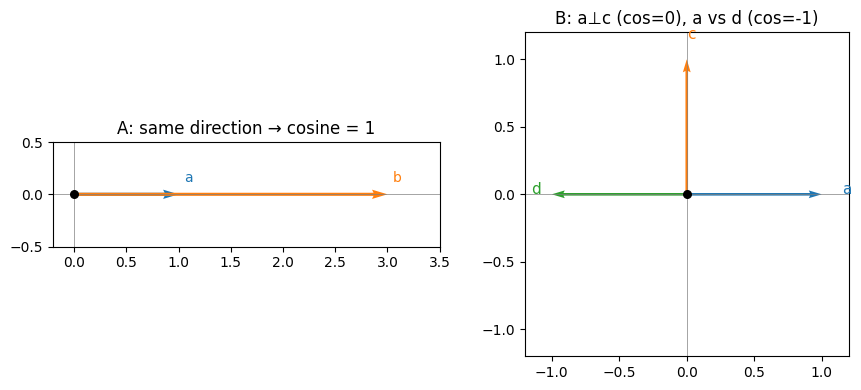

In [31]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Example A: same direction, different lengths
ax = axes[0]
a = np.array([1.0, 0.0])
b = np.array([3.0, 0.0])
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.quiver(0, 0, a[0], a[1], angles="xy", scale_units="xy", scale=1, color="C0", width=0.008)
ax.quiver(0, 0, b[0], b[1], angles="xy", scale_units="xy", scale=1, color="C1", width=0.008)
ax.scatter([0], [0], c="k", s=30, zorder=5)
ax.set_xlim(-0.2, 3.5)
ax.set_ylim(-0.5, 0.5)
ax.set_aspect("equal")
ax.set_title("A: same direction → cosine = 1")
ax.text(1.05, 0.12, "a", color="C0")
ax.text(3.05, 0.12, "b", color="C1")

# Example B: orthogonal c and opposite d
ax = axes[1]
a = np.array([1.0, 0.0])
c = np.array([0.0, 1.0])
d = np.array([-1.0, 0.0])
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
for v, col, lab in [(a, "C0", "a"), (c, "C1", "c"), (d, "C2", "d")]:
    ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1, color=col, width=0.008)
    ax.text(v[0] * 1.15, v[1] * 1.15, lab, color=col, fontsize=11)
ax.scatter([0], [0], c="k", s=30, zorder=5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.set_title("B: a⊥c (cos=0), a vs d (cos=-1)")

plt.tight_layout()
plt.show()


Similarity helpers use **NumPy** (`np`). The import is in the cell that defines `dot_product` (below the matplotlib figure).


In [32]:
import numpy as np

def dot_product(a, b):
    return np.dot(a, b)

In [33]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [34]:
def euclidean_distance(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.linalg.norm(a - b)

In [35]:
print("=== Cosine Similarity (Higher is better) ===")
print("Range: -1 to 1")

print("\n=== Dot Product (Higher is better) ===")
print("Range: -∞ to +∞ (depends on vector magnitude)")

print("\n=== Euclidean Distance (Lower is better) ===")
print("Range: 0 to +∞")

=== Cosine Similarity (Higher is better) ===
Range: -1 to 1

=== Dot Product (Higher is better) ===
Range: -∞ to +∞ (depends on vector magnitude)

=== Euclidean Distance (Lower is better) ===
Range: 0 to +∞


Embed the **query** once and each **document** with the same model (`text-embedding-3-large` here). Then compare vectors with the three metrics above. Heart-health sentences should score higher than the unrelated car sentence.


In [36]:
query = "How to reduce heart disease risk?"

In [37]:
documents = [
    "Eating fiber reduces heart risk.",
    "Fruits and vegetables lower cardiovascular disease chances.",
    "Buying a new car improves driving comfort.",
    "Regular exercise improves heart health."
]

In [38]:
query_embedding = openai_embeddings_model.embed_query(query)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: <YOUR_OP*********KEY>. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [65]:
doc_embeddings = openai_embeddings_model.embed_documents(documents)

In [66]:
len(doc_embeddings)

4

In [67]:
len(doc_embeddings[0])

3072

In [69]:
results = []

In [39]:
for doc, doc_emb in zip(documents, doc_embeddings):
    results.append({
        "query": query,
        "document": doc,
        "cosine": cosine_similarity(query_embedding, doc_emb),
        "dot_product": dot_product(query_embedding, doc_emb),
        "euclidean": euclidean_distance(query_embedding, doc_emb)
    })

NameError: name 'doc_embeddings' is not defined

In [71]:
results

[{'query': 'How to reduce heart disease risk?',
  'document': 'Eating fiber reduces heart risk.',
  'cosine': 0.5985462508876028,
  'dot_product': 0.5986208614314315,
  'euclidean': 0.8961069525957198},
 {'query': 'How to reduce heart disease risk?',
  'document': 'Fruits and vegetables lower cardiovascular disease chances.',
  'cosine': 0.5578602807682239,
  'dot_product': 0.5577105806559395,
  'euclidean': 0.9402351589986666},
 {'query': 'How to reduce heart disease risk?',
  'document': 'Buying a new car improves driving comfort.',
  'cosine': 0.06057430919232074,
  'dot_product': 0.060568684150503316,
  'euclidean': 1.3706483553936326},
 {'query': 'How to reduce heart disease risk?',
  'document': 'Regular exercise improves heart health.',
  'cosine': 0.4914256906935539,
  'dot_product': 0.491606805490445,
  'euclidean': 1.0087238371978915}]

## 6. Keyword search (lexical overlap)

Unlike embeddings, **keyword search** matches shared words (after lowercasing and simple punctuation stripping). The demo scores each document by **how often query words appear** in the document (see `keyword_search`).

This can miss synonyms (e.g. *heart* vs *cardiovascular*) unless both words appear—compare to semantic search above.


In [40]:
documents

['Eating fiber reduces heart risk.',
 'Fruits and vegetables lower cardiovascular disease chances.',
 'Buying a new car improves driving comfort.',
 'Regular exercise improves heart health.']

In [41]:
query

'How to reduce heart disease risk?'

In [42]:
from collections import Counter

In [43]:
query.lower().replace("?", "").split()

['how', 'to', 'reduce', 'heart', 'disease', 'risk']

In [44]:
query_words = query.lower().replace("?", "").split()

In [45]:
documents[0]

'Eating fiber reduces heart risk.'

In [46]:
doc_words = documents[0].lower().replace(".", "").split()

In [47]:
doc_words

['eating', 'fiber', 'reduces', 'heart', 'risk']

In [48]:
doc_count = Counter(doc_words)

In [49]:
doc_count

Counter({'eating': 1, 'fiber': 1, 'reduces': 1, 'heart': 1, 'risk': 1})

In [50]:
for word in query_words:
    print(f"{word}: {doc_count[word]}")

how: 0
to: 0
reduce: 0
heart: 1
disease: 0
risk: 1


In [51]:
score = sum(doc_count[word] for word in query_words) 

**Scoring:** `score` sums, for each query word, the count of that word in the document (often 0 or 1 per word in this simple tokenizer).


In [52]:
score

2

In [53]:
def keyword_search(query, documents):
    query_words = query.lower().replace("?", "").split()
    results = []

    for doc in documents:
        doc_words = doc.lower().replace(".", "").split()
        doc_count = Counter(doc_words)

        score = sum(doc_count[word] for word in query_words) 
        results.append((doc, score))

    return sorted(results, key=lambda x: x[1], reverse=True)

In [54]:
keyword_results = keyword_search(query, documents)

In [55]:
keyword_results

[('Eating fiber reduces heart risk.', 2),
 ('Fruits and vegetables lower cardiovascular disease chances.', 1),
 ('Regular exercise improves heart health.', 1),
 ('Buying a new car improves driving comfort.', 0)]

---

### Summary

- **MiniLM** (local): 384-d text embeddings. **Gemini / OpenAI** APIs: different sizes (e.g. 3072 / 1536). **CLIP** image: 512-d for this checkpoint.
- **Semantic** retrieval ranks by vector similarity; **keyword** retrieval ranks by exact word overlap.
- For production RAG, you often normalize vectors and use **cosine** or **inner product** in a vector database.
